# 🏥 Notebook 01 – Tiền xử lý & Huấn luyện: TIỂU ĐƯỜNG
**Dataset:** `diabetes_dataset_with_notes.csv` (100,000 mẫu)  
**Sinh viên:** Lê Trung Hiếu – 102220187

---
### ⚠️ Các vấn đề xử lý đặc thù của dataset này
| # | Vấn đề | Xử lý |
|---|--------|-------|
| 1 | `clinical_notes` chứa từ "diabetes" trong 86% dòng | **DROP ngay** – data leakage nghiêm trọng |
| 2 | `location`, `year`, `race:*` → shortcut learning | **DROP** |
| 3 | `smoking_history` = "No Info" (35.8%) | Encode thành nhóm riêng = 0 |
| 4 | Mất cân bằng 91.5%/8.5% | SMOTE (chỉ trên train) |
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 PHẦN 0: IMPORT

In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap, joblib, os

# ==============================================================
# ✅ KHAI BÁO ĐƯỜNG DẪN ROOT ĐẾN GOOGLE DRIVE
# ==============================================================
DRIVE_PATH = '/content/drive/MyDrive/DATN_HealthRisk'
DIR_DATA = f'{DRIVE_PATH}/data'
DIR_MODELS = f'{DRIVE_PATH}/models'
DIR_RESULTS = f'{DRIVE_PATH}/results'

for d in [DIR_DATA, DIR_MODELS, DIR_RESULTS]:
    os.makedirs(d, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid'); sns.set_palette("husl")
print("✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!")

✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!


---
## 📋 PHẦN 1: KHÁM PHÁ DỮ LIỆU
### 1.1 Load và tổng quan

In [3]:
file_path = '/content/drive/MyDrive/DATN_HealthRisk/data/diabetes_dataset_with_notes.csv'
df_raw = pd.read_csv(file_path)

print("=" * 68)
print("📊 DIABETES DATASET WITH NOTES  –  100,000 bệnh nhân")
print("=" * 68)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {df_raw.columns.tolist()}")
display(df_raw.head(3))
display(df_raw.describe().round(2))

📊 DIABETES DATASET WITH NOTES  –  100,000 bệnh nhân
  Shape   : (100000, 17)
  Columns : ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes', 'clinical_notes']


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.0,100000.0,100000.0,100000.0,100000.0,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,2018.36,41.89,0.2,0.2,0.2,0.2,0.2,0.07,0.04,27.32,5.53,138.06,0.08
std,1.35,22.52,0.4,0.4,0.4,0.4,0.4,0.26,0.19,6.64,1.07,40.71,0.28
min,2015.00,0.08,0.0,0.0,0.0,0.0,0.0,0.00,0.00,10.01,3.50,80.00,0.00
25%,2019.00,24.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,23.63,4.80,100.00,0.00
50%,2019.00,43.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,27.32,5.80,140.00,0.00
75%,2019.00,60.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,29.58,6.20,159.00,0.00
max,2022.00,80.00,1.0,1.0,1.0,1.0,1.0,1.00,1.00,95.69,9.00,300.00,1.00


### 1.2 Phân tích data leakage trong `clinical_notes`

In [4]:
print("🚨 KIỂM TRA DATA LEAKAGE clinical_notes")
print("=" * 68)

keywords = {'diabetes': 'chứa từ chẩn đoán chính',
            'glucose' : 'chứa chỉ số xét nghiệm',
            'HbA1c'   : 'chứa chỉ số xét nghiệm'}
for kw, note in keywords.items():
    n = df_raw['clinical_notes'].str.lower().str.contains(kw.lower(), na=False).sum()
    print(f"  '{kw}' ({note}): {n:,} hàng ({n/len(df_raw)*100:.1f}%)")

# Ví dụ trực quan
print("\n  Ví dụ clinical_notes của NGƯỜI CÓ tiểu đường:")
sample = df_raw[df_raw['diabetes']==1]['clinical_notes'].dropna().iloc[0]
print(f"  → {sample[:120]}...")

print("\n  ❌ KẾT LUẬN: clinical_notes gần như chép lại kết quả chẩn đoán.")
print("     Đây là DATA LEAKAGE nghiêm trọng → PHẢI DROP trước khi train!")

# Columns to drop analysis
print("\n⚠️  CÁC CỘT CẦN DROP VÀ LÝ DO:")
drops = {
    'clinical_notes'   : 'Data leakage chứa chẩn đoán trong văn bản',
    'year'             : 'Temporal leakage mô hình học theo năm, không phải triệu chứng',
    'location'         : 'Shortcut learning các bang có tỷ lệ bệnh khác nhau',
    'race:AfricanAmerican': 'Fairness concern + shortcut learning',
    'race:Asian'       : 'Fairness concern + shortcut learning',
    'race:Caucasian'   : 'Fairness concern + shortcut learning',
    'race:Hispanic'    : 'Fairness concern + shortcut learning',
    'race:Other'       : 'Fairness concern + shortcut learning',
}
for col, reason in drops.items():
    print(f"  DROP '{col}': {reason}")

🚨 KIỂM TRA DATA LEAKAGE clinical_notes
  'diabetes' (chứa từ chẩn đoán chính): 86,059 hàng (86.1%)
  'glucose' (chứa chỉ số xét nghiệm): 70,608 hàng (70.6%)
  'HbA1c' (chứa chỉ số xét nghiệm): 20,797 hàng (20.8%)

  Ví dụ clinical_notes của NGƯỜI CÓ tiểu đường:
  → Elderly patient with increased risk of chronic conditions. Obese category, increased risk for diabetes and cardiovascula...

  ❌ KẾT LUẬN: clinical_notes gần như chép lại kết quả chẩn đoán.
     Đây là DATA LEAKAGE nghiêm trọng → PHẢI DROP trước khi train!

⚠️  CÁC CỘT CẦN DROP VÀ LÝ DO:
  DROP 'clinical_notes': Data leakage chứa chẩn đoán trong văn bản
  DROP 'year': Temporal leakage mô hình học theo năm, không phải triệu chứng
  DROP 'location': Shortcut learning các bang có tỷ lệ bệnh khác nhau
  DROP 'race:AfricanAmerican': Fairness concern + shortcut learning
  DROP 'race:Asian': Fairness concern + shortcut learning
  DROP 'race:Caucasian': Fairness concern + shortcut learning
  DROP 'race:Hispanic': Fairness concern + 

### 1.3 Phân tích phân phối và mất cân bằng nhãn

⚖️  PHÂN PHỐI NHÃN
  Class 0 Không tiểu đường: 91,500  (91.5%)
  Class 1 Có tiểu đường   : 8,500  (8.5%)
  Tỷ lệ mất cân bằng        : 10.8:1  → Cần SMOTE

📊 PHÂN TÍCH FEATURE THEO NHÃN:
  age                      : không bệnh=40.12  có bệnh=60.95  Δ=+51.9%
  bmi                      : không bệnh=26.89  có bệnh=31.99  Δ=+19.0%
  hbA1c_level              : không bệnh=5.40  có bệnh=6.93  Δ=+28.5%
  blood_glucose_level      : không bệnh=132.85  có bệnh=194.09  Δ=+46.1%


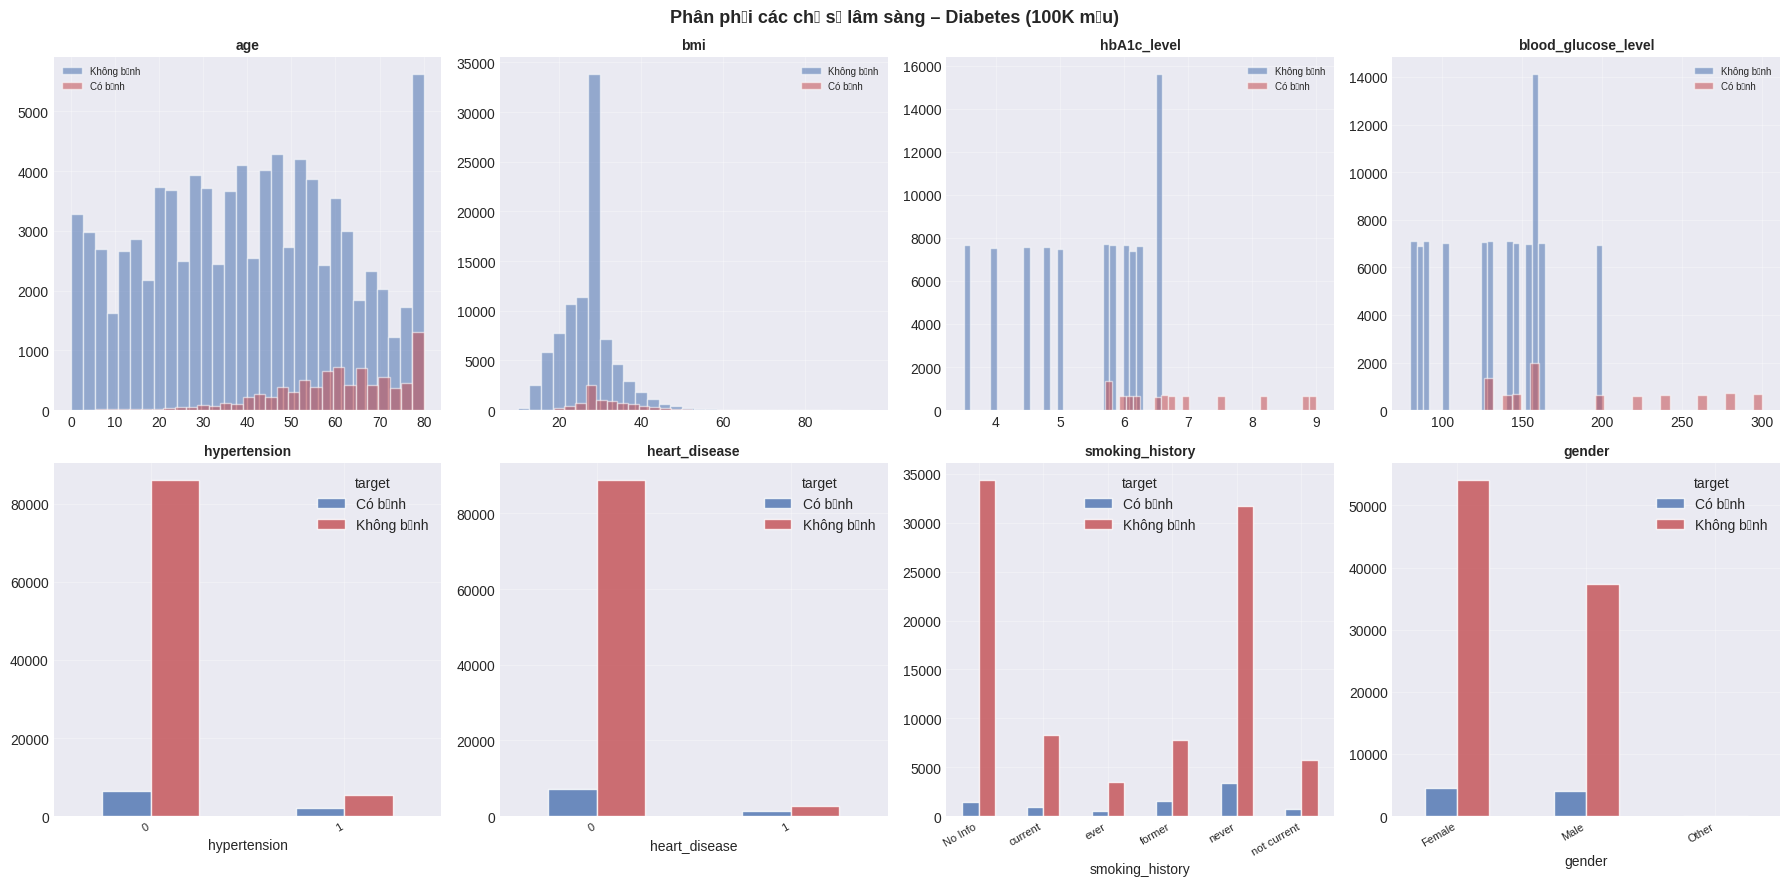

✅ Đã lưu biểu đồ EDA


In [5]:
print("⚖️  PHÂN PHỐI NHÃN")
target_vc = df_raw['diabetes'].value_counts()
print(f"  Class 0 Không tiểu đường: {target_vc[0]:,}  ({target_vc[0]/len(df_raw)*100:.1f}%)")
print(f"  Class 1 Có tiểu đường   : {target_vc[1]:,}  ({target_vc[1]/len(df_raw)*100:.1f}%)")
print(f"  Tỷ lệ mất cân bằng        : {target_vc[0]/target_vc[1]:.1f}:1  → Cần SMOTE")

print("\n📊 PHÂN TÍCH FEATURE THEO NHÃN:")
num_feats = ['age','bmi','hbA1c_level','blood_glucose_level']
for f in num_feats:
    m0 = df_raw[df_raw['diabetes']==0][f].mean()
    m1 = df_raw[df_raw['diabetes']==1][f].mean()
    diff_pct = (m1-m0)/m0*100
    print(f"  {f:25s}: không bệnh={m0:.2f}  có bệnh={m1:.2f}  Δ={diff_pct:+.1f}%")

# Biểu đồ EDA
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Phân phối các chỉ số lâm sàng – Diabetes (100K mẫu)',fontsize=13,weight='bold')
plot_cols = ['age','bmi','hbA1c_level','blood_glucose_level',
             'hypertension','heart_disease','smoking_history','gender']
for idx, col in enumerate(plot_cols):
    ax = axes[idx//4, idx%4]
    if df_raw[col].dtype == object or df_raw[col].nunique() <= 6:
        tmp = df_raw.copy()
        tmp['target'] = tmp['diabetes'].map({0:'Không bệnh',1:'Có bệnh'})
        ct = tmp.groupby([col,'target']).size().unstack(fill_value=0)
        ct.plot(kind='bar', ax=ax, color=['#4C72B0','#C44E52'], alpha=0.8, edgecolor='white')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    else:
        for label, color, name in [(0,'#4C72B0','Không bệnh'),(1,'#C44E52','Có bệnh')]:
            ax.hist(df_raw[df_raw['diabetes']==label][col], bins=30,
                    alpha=0.55, color=color, label=name, edgecolor='white')
        ax.legend(fontsize=7)
    ax.set_title(col, fontsize=10, weight='bold')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu biểu đồ EDA")

---
## ⚙️ PHẦN 2: TIỀN XỬ LÝ
### 2.1 Drop cột nguy hiểm

In [6]:
df = df_raw.copy()

DROP_COLS = ['clinical_notes','year','location',
             'race:AfricanAmerican','race:Asian','race:Caucasian',
             'race:Hispanic','race:Other']
df = df.drop(columns=DROP_COLS)

print(f"✓ Dropped {len(DROP_COLS)} cột nguy hiểm")
print(f"✓ Còn lại: {df.columns.tolist()}")
print(f"✓ Shape  : {df.shape}")

✓ Dropped 8 cột nguy hiểm
✓ Còn lại: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']
✓ Shape  : (100000, 9)


### 2.2 Encode `gender` và `smoking_history`

In [7]:
print("🔄 ENCODING CATEGORICAL FEATURES")
print("=" * 60)

# ── gender ────────────────────────────────────────────────────
# 'Other' = 18 rows (0.018%) → gộp vào Female=0 hoặc drop
print(f"  gender distribution: {df['gender'].value_counts().to_dict()}")
df = df[df['gender'] != 'Other'].copy()   # drop 18 dòng 'Other'
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
print(f"  ✓ gender: Female=0, Male=1  (dropped 18 rows 'Other')")

# ── smoking_history ───────────────────────────────────────────
# Thứ tự lâm sàng theo mức độ phơi nhiễm:
# No Info = 0 (unknown), never = 1, ever/not current = 2, former = 3, current = 4
print(f"\n  smoking_history distribution:")
print(df['smoking_history'].value_counts().to_string())

smoking_map = {
    'No Info'     : 0,   # không rõ thông tin
    'never'       : 1,   # chưa bao giờ hút
    'not current' : 2,   # đã hút nhưng không còn hiện tại
    'ever'        : 2,   # từng hút (không rõ thời điểm)
    'former'      : 3,   # đã từng hút, đã bỏ
    'current'     : 4,   # đang hút thuốc (nguy cơ cao nhất)
}
df['smoking_history'] = df['smoking_history'].map(smoking_map)
print(f"\n  ✓ smoking_history encoded: No Info=0, never=1, ever/not current=2, former=3, current=4")
print(f"  ✓ Phân phối sau encode:")
print(df['smoking_history'].value_counts().sort_index().to_string())
print(f"\n✅ Null sau encode: {df.isnull().sum().sum()}")
print(f"✅ Shape: {df.shape}")

🔄 ENCODING CATEGORICAL FEATURES
  gender distribution: {'Female': 58552, 'Male': 41430, 'Other': 18}
  ✓ gender: Female=0, Male=1  (dropped 18 rows 'Other')

  smoking_history distribution:
smoking_history
No Info        35810
never          35092
former          9352
current         9286
not current     6439
ever            4003

  ✓ smoking_history encoded: No Info=0, never=1, ever/not current=2, former=3, current=4
  ✓ Phân phối sau encode:
smoking_history
0    35810
1    35092
2    10442
3     9352
4     9286

✅ Null sau encode: 0
✅ Shape: (99982, 9)


### 2.3 Kiểm tra giá trị bất thường

In [8]:
print("🔍 KIỂM TRA GIÁ TRỊ BẤT THƯỜNG")
print("=" * 60)

checks = {
    'age'               : (0, 120,  "tuổi hợp lệ"),
    'bmi'               : (10, 70,  "BMI hợp lệ"),
    'hbA1c_level'       : (3.0, 15, "HbA1c hợp lệ"),
    'blood_glucose_level': (50, 500, "Glucose hợp lệ"),
}
total_invalid = 0
for col, (lo, hi, note) in checks.items():
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    if n_lo + n_hi > 0:
        print(f"  ⚠️  {col}: {n_lo} < {lo} | {n_hi} > {hi}  ({note})")
        total_invalid += n_lo + n_hi
    else:
        print(f"  ✓  {col}: tất cả trong range [{lo}, {hi}]")

print(f"\n  Tổng giá trị bất thường: {total_invalid}")
if total_invalid == 0:
    print("  ✅ Dataset sạch – không cần clip/remove thêm!")

# Correlation
print("\n📊 CORRELATION VỚI NHÃN:")
corr = df.corr()['diabetes'].drop('diabetes').abs().sort_values(ascending=False)
for f, v in corr.items():
    bar = '█' * int(v*30)
    print(f"  {f:25s} |{bar:<30}| {v:.3f}")

🔍 KIỂM TRA GIÁ TRỊ BẤT THƯỜNG
  ✓  age: tất cả trong range [0, 120]
  ⚠️  bmi: 0 < 10 | 19 > 70  (BMI hợp lệ)
  ✓  hbA1c_level: tất cả trong range [3.0, 15]
  ✓  blood_glucose_level: tất cả trong range [50, 500]

  Tổng giá trị bất thường: 19

📊 CORRELATION VỚI NHÃN:
  blood_glucose_level       |████████████                  | 0.420
  hbA1c_level               |████████████                  | 0.401
  age                       |███████                       | 0.258
  bmi                       |██████                        | 0.214
  hypertension              |█████                         | 0.198
  heart_disease             |█████                         | 0.172
  smoking_history           |███                           | 0.110
  gender                    |█                             | 0.038


### 2.4 Correlation matrix

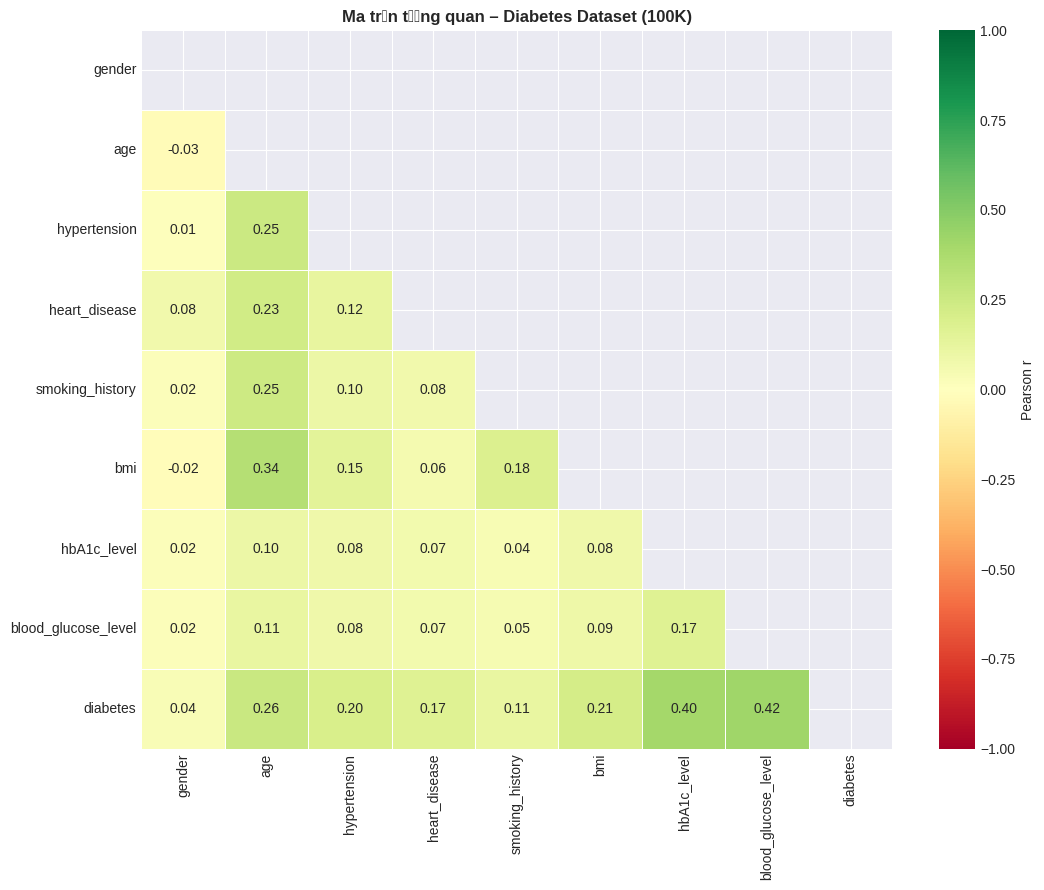

In [9]:
plt.figure(figsize=(11, 9))
corr_full = df.corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title('Ma trận tương quan – Diabetes Dataset (100K)', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔀 PHẦN 3: SPLIT → SMOTE → SCALE

Features cuối cùng dùng để train:
   1. gender
   2. age
   3. hypertension
   4. heart_disease
   5. smoking_history
   6. bmi
   7. hbA1c_level
   8. blood_glucose_level
  Tổng: 8 features

BƯỚC 1: Stratified 80/20 Split
  Train: 79,985  |  Test: 19,997
  Train class: {0: np.int64(73185), 1: np.int64(6800)}
  Test  class: {0: np.int64(18297), 1: np.int64(1700)}

BƯỚC 2: SMOTE (chỉ trên train)
  79,985 → 146,370 mẫu sau SMOTE
  Class dist: {0: np.int64(73185), 1: np.int64(73185)}

BƯỚC 3: StandardScaler (fit train only)

💾 Lưu: diabetes_scaler.pkl | diabetes_features.pkl | diabetes_test_raw.pkl


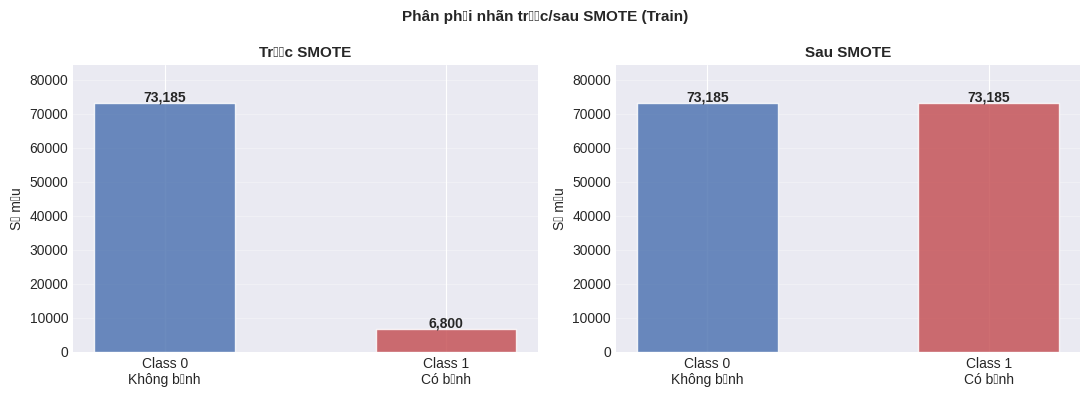

In [10]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']
FEATURE_NAMES = X.columns.tolist()

print("Features cuối cùng dùng để train:")
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f"  {i:2d}. {f}")
print(f"  Tổng: {len(FEATURE_NAMES)} features")

# ── BƯỚC 1: Split ──────────────────────────────────────────────────────────────
print("\nBƯỚC 1: Stratified 80/20 Split")
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"  Train: {X_train_raw.shape[0]:,}  |  Test: {X_test_raw.shape[0]:,}")
print(f"  Train class: {dict(y_train_raw.value_counts().sort_index())}")
print(f"  Test  class: {dict(y_test_raw.value_counts().sort_index())}")

# ── BƯỚC 2: SMOTE (chỉ trên train) ────────────────────────────────────────────
print("\nBƯỚC 2: SMOTE (chỉ trên train)")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
print(f"  {X_train_raw.shape[0]:,} → {X_train_res.shape[0]:,} mẫu sau SMOTE")
print(f"  Class dist: {dict(pd.Series(y_train_res).value_counts().sort_index())}")

# ── BƯỚC 3: Scale ─────────────────────────────────────────────────────────────
print("\nBƯỚC 3: StandardScaler (fit train only)")
scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_res)
X_test_d  = scaler.transform(X_test_raw)
y_train_d = y_train_res
y_test_d  = y_test_raw.values

joblib.dump(scaler,        f'{DIR_MODELS}/diabetes_scaler.pkl')
joblib.dump(FEATURE_NAMES, f'{DIR_MODELS}/diabetes_features.pkl')
joblib.dump((X_test_raw.values, y_test_raw.values), f'{DIR_MODELS}/diabetes_test_raw.pkl')
print("\n💾 Lưu: diabetes_scaler.pkl | diabetes_features.pkl | diabetes_test_raw.pkl")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [(axes[0], y_train_raw, "Trước SMOTE"),
                         (axes[1], pd.Series(y_train_res), "Sau SMOTE")]:
    vc = pd.Series(data).value_counts().sort_index()
    bars = ax.bar(['Class 0\nKhông bệnh', 'Class 1\nCó bệnh'], vc.values,
                  color=['#4C72B0','#C44E52'], alpha=0.82, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                f'{val:,}', ha='center', fontsize=10, weight='bold')
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_ylabel('Số mẫu'); ax.set_ylim(0, max(vc.values)*1.15)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Phân phối nhãn trước/sau SMOTE (Train)', fontsize=11, weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D03_smote_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 PHẦN 4: HUẤN LUYỆN MÔ HÌNH
### 4.1 XGBoost + GridSearchCV

In [11]:
print("🚀 XGBOOST + GRIDSEARCHCV (scoring=roc_auc)")
print("=" * 68)

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
}
total = 1
for v in param_grid.values(): total *= len(v)
print(f"  Tổng tổ hợp: {total} × 5-fold = {total*5} lần fit")

xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                               random_state=42, verbosity=0,
                             tree_method='hist',
    device='cuda')
cv_str = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(xgb_base, param_grid, cv=cv_str,
                  scoring='roc_auc', n_jobs=1, verbose=1, refit=True)
gs.fit(X_train_d, y_train_d)
best_xgb = gs.best_estimator_

print("\n✅ Best parameters:")
for k, v in gs.best_params_.items():
    print(f"   {k:25s}: {v}")
print(f"\n  Best CV AUC-ROC: {gs.best_score_:.4f}")
joblib.dump(best_xgb, f'{DIR_MODELS}/diabetes_xgboost.pkl')
print("💾 Lưu: diabetes_xgboost.pkl")

🚀 XGBOOST + GRIDSEARCHCV (scoring=roc_auc)
  Tổng tổ hợp: 216 × 5-fold = 1080 lần fit
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Best parameters:
   colsample_bytree         : 1.0
   learning_rate            : 0.1
   max_depth                : 7
   min_child_weight         : 1
   n_estimators             : 300
   subsample                : 0.8

  Best CV AUC-ROC: 0.9972
💾 Lưu: diabetes_xgboost.pkl


### 4.2 Đánh giá trên Test Set

📊 ĐÁNH GIÁ XGBOOST – DIABETES (Test set 20,000 mẫu)
  Metric     │ Score   │ Min   │ Trạng thái
  ──────────────────────────────────────────────────
  Accuracy   │  0.9659 │ ≥0.8 │ ✅ ĐẠT
  Precision  │  0.8621 │ ≥0.75 │ ✅ ĐẠT
  Recall     │  0.7135 │ ≥0.75 │ ❌ CHƯA ĐẠT
  F1         │  0.7808 │ ≥0.78 │ ✅ ĐẠT
  AUC        │  0.9737 │ ≥0.82 │ ✅ ĐẠT

              precision    recall  f1-score   support

  Không bệnh       0.97      0.99      0.98     18297
     Có bệnh       0.86      0.71      0.78      1700

    accuracy                           0.97     19997
   macro avg       0.92      0.85      0.88     19997
weighted avg       0.96      0.97      0.96     19997



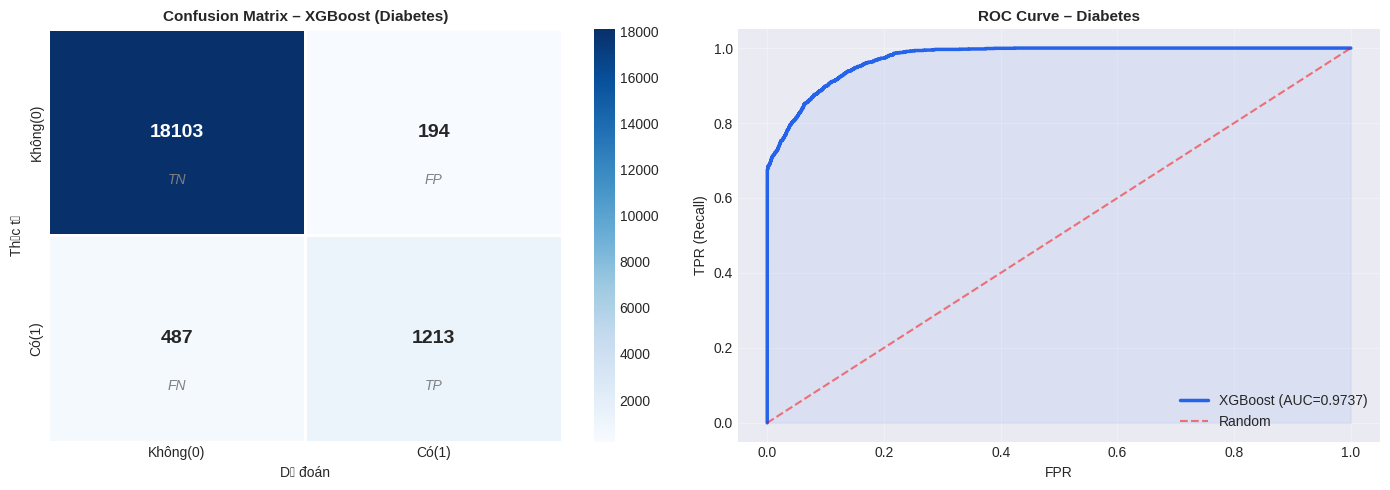

  TP=1,213 | TN=18,103 | FP=194 | FN=487
  Sensitivity=0.7135 | Specificity=0.9894


In [12]:
y_pred_xgb = best_xgb.predict(X_test_d)
y_prob_xgb = best_xgb.predict_proba(X_test_d)[:, 1]
acc_xgb  = accuracy_score(y_test_d, y_pred_xgb)
prec_xgb = precision_score(y_test_d, y_pred_xgb)
rec_xgb  = recall_score(y_test_d, y_pred_xgb)
f1_xgb   = f1_score(y_test_d, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test_d, y_prob_xgb)

THRESH = {'Accuracy':0.80,'Precision':0.75,'Recall':0.75,'F1':0.78,'AUC':0.82}
SCORES = {'Accuracy':acc_xgb,'Precision':prec_xgb,'Recall':rec_xgb,'F1':f1_xgb,'AUC':auc_xgb}
print("📊 ĐÁNH GIÁ XGBOOST – DIABETES (Test set 20,000 mẫu)")
print("=" * 68)
print(f"  {'Metric':10s} │ {'Score':7s} │ Min   │ Trạng thái")
print("  " + "─"*50)
for name, val in SCORES.items():
    thr = THRESH[name]
    print(f"  {name:10s} │  {val:.4f} │ ≥{thr} │ {'✅ ĐẠT' if val>=thr else '❌ CHƯA ĐẠT'}")
print(f"\n{classification_report(y_test_d, y_pred_xgb, target_names=['Không bệnh','Có bệnh'])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_d, y_pred_xgb)
tn,fp,fn,tp = cm.ravel()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không(0)','Có(1)'], yticklabels=['Không(0)','Có(1)'],
            linewidths=1, linecolor='white', annot_kws={'size':14,'weight':'bold'})
axes[0].set_title('Confusion Matrix – XGBoost (Diabetes)',fontsize=11,weight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')
for (i,j), label in [((0,0),'TN'),((0,1),'FP'),((1,0),'FN'),((1,1),'TP')]:
    axes[0].text(j+0.5, i+0.75, label, ha='center', color='gray', style='italic', fontsize=10)
fpr,tpr,_ = roc_curve(y_test_d, y_prob_xgb)
axes[1].plot(fpr, tpr, color='#2563eb', lw=2.5, label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot([0,1],[0,1],'r--',lw=1.5,alpha=0.5,label='Random')
axes[1].fill_between(fpr,tpr,alpha=0.08,color='#2563eb')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR (Recall)')
axes[1].set_title('ROC Curve – Diabetes',fontsize=11,weight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D04_xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}")
print(f"  Sensitivity={tp/(tp+fn):.4f} | Specificity={tn/(tn+fp):.4f}")

### 4.3 Threshold Tuning (F2 – ưu tiên Recall)

  Ngưỡng F2 tối ưu: 0.2274
  Recall   : 0.8494
  Precision: 0.5556
  F1-Score : 0.6718

💾 Lưu: diabetes_thresholds.pkl  (f2_medical=0.2274)


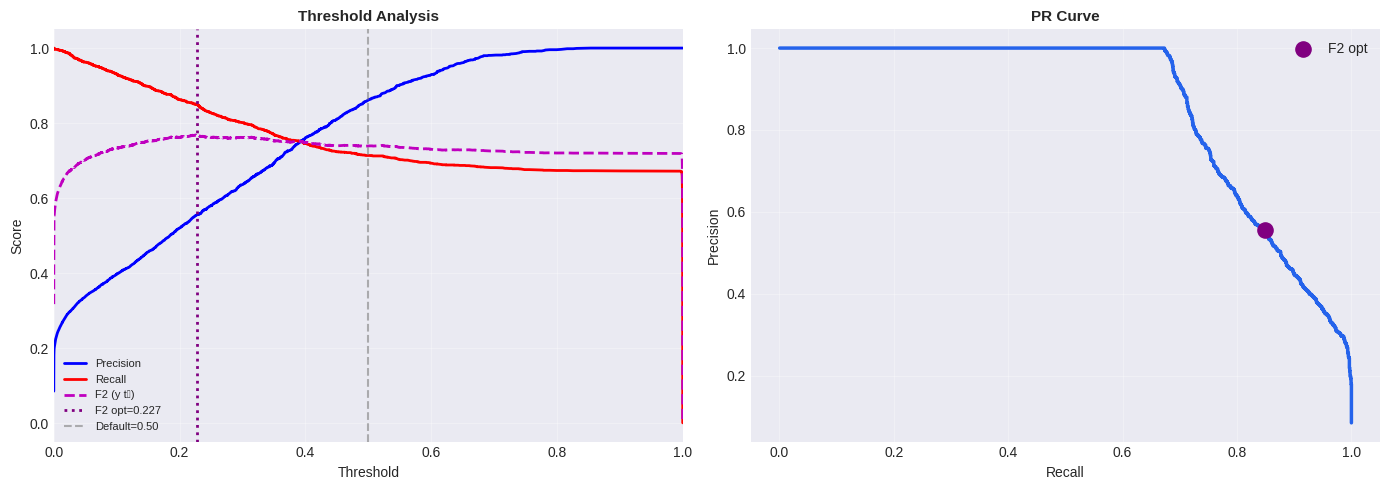

In [13]:
precisions, recalls, thresholds = precision_recall_curve(y_test_d, y_prob_xgb)
f2_scores = (5*(precisions[:-1]*recalls[:-1]))/(4*precisions[:-1]+recalls[:-1]+1e-8)
best_t_f2 = thresholds[np.argmax(f2_scores)]
f1_scores_t = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1]+1e-8)
best_t_f1 = thresholds[np.argmax(f1_scores_t)]

y_pred_tuned = (y_prob_xgb >= best_t_f2).astype(int)
print(f"  Ngưỡng F2 tối ưu: {best_t_f2:.4f}")
print(f"  Recall   : {recall_score(y_test_d, y_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_test_d, y_pred_tuned):.4f}")
print(f"  F1-Score : {f1_score(y_test_d, y_pred_tuned):.4f}")
joblib.dump({'default':0.5,'f1':float(best_t_f1),'f2_medical':float(best_t_f2)},
            f'{DIR_MODELS}/diabetes_thresholds.pkl')
print(f"\n💾 Lưu: diabetes_thresholds.pkl  (f2_medical={best_t_f2:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, precisions[:-1],'b-',lw=2,label='Precision')
axes[0].plot(thresholds, recalls[:-1],'r-',lw=2,label='Recall')
axes[0].plot(thresholds, f2_scores,'m--',lw=2,label='F2 (y tế)')
axes[0].axvline(x=best_t_f2,color='purple',linestyle=':',lw=2,label=f'F2 opt={best_t_f2:.3f}')
axes[0].axvline(x=0.5,color='gray',linestyle='--',lw=1.5,alpha=0.6,label='Default=0.50')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Analysis',fontsize=11,weight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.3); axes[0].set_xlim([0,1])
axes[1].plot(recalls[:-1], precisions[:-1], color='#2563eb', lw=2.5)
bi = np.argmax(f2_scores)
axes[1].scatter([recalls[bi]],[precisions[bi]],color='purple',s=120,zorder=5,label='F2 opt')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve',fontsize=11,weight='bold')
axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D05_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Random Forest + So sánh

💾 Lưu: diabetes_randomforest.pkl

🏆 XGBoost vs Random Forest – DIABETES
  Metric       │ XGBoost  │ RandomForest │ Winner
  ───────────────────────────────────────────────────────
  Accuracy     │  0.9659 │    0.9048    │ XGBoost ✅
  Precision    │  0.8621 │    0.4670    │ XGBoost ✅
  Recall       │  0.7135 │    0.8447    │ RF      ✅
  F1-Score     │  0.7808 │    0.6015    │ XGBoost ✅
  AUC-ROC      │  0.9737 │    0.9648    │ XGBoost ✅


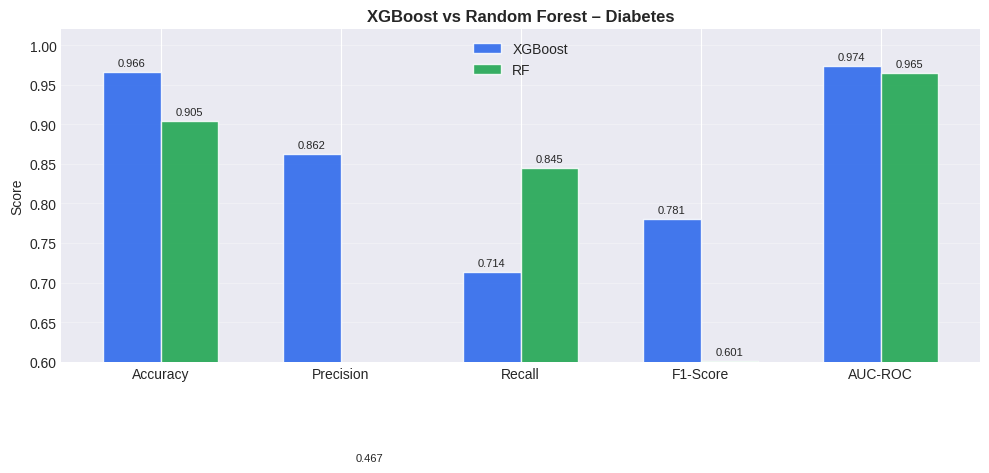

In [14]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1,
    class_weight='balanced')
rf_model.fit(X_train_d, y_train_d)
joblib.dump(rf_model, f'{DIR_MODELS}/diabetes_randomforest.pkl')

y_pred_rf = rf_model.predict(X_test_d)
y_prob_rf  = rf_model.predict_proba(X_test_d)[:,1]
acc_rf,prec_rf,rec_rf = accuracy_score(y_test_d,y_pred_rf),precision_score(y_test_d,y_pred_rf),recall_score(y_test_d,y_pred_rf)
f1_rf,auc_rf = f1_score(y_test_d,y_pred_rf),roc_auc_score(y_test_d,y_prob_rf)
print("💾 Lưu: diabetes_randomforest.pkl")

metrics_n = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
xgb_s = [acc_xgb,prec_xgb,rec_xgb,f1_xgb,auc_xgb]
rf_s  = [acc_rf,prec_rf,rec_rf,f1_rf,auc_rf]
print("\n🏆 XGBoost vs Random Forest – DIABETES")
print(f"  {'Metric':12s} │ {'XGBoost':8s} │ {'RandomForest':12s} │ Winner")
print("  " + "─"*55)
for n,xv,rv in zip(metrics_n,xgb_s,rf_s):
    w = "XGBoost ✅" if xv>=rv else "RF      ✅"
    print(f"  {n:12s} │  {xv:.4f} │    {rv:.4f}    │ {w}")

fig,ax = plt.subplots(figsize=(10,5))
x=np.arange(len(metrics_n)); w=0.32
b1=ax.bar(x-w/2,xgb_s,w,label='XGBoost',color='#2563eb',alpha=0.85,edgecolor='white')
b2=ax.bar(x+w/2,rf_s, w,label='RF',      color='#16a34a',alpha=0.85,edgecolor='white')
for bars in [b1,b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                f'{bar.get_height():.3f}',ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_n)
ax.set_ylim([0.60,1.02]); ax.set_ylabel('Score')
ax.set_title('XGBoost vs Random Forest – Diabetes',fontsize=12,weight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Cross-Validation Report

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(best_xgb, X_train_d, y_train_d,
    cv=cv, scoring={'accuracy':'accuracy','precision':'precision',
                    'recall':'recall','f1':'f1','roc_auc':'roc_auc'}, n_jobs=-1)
print("📊 5-FOLD CV – DIABETES XGBOOST")
print(f"  {'Metric':12s} │ Mean   ± Std    │ Min    │ Max")
print("  " + "─"*52)
for m,k in [('Accuracy','test_accuracy'),('Precision','test_precision'),
            ('Recall','test_recall'),('F1','test_f1'),('AUC-ROC','test_roc_auc')]:
    v=cv_res[k]
    flag = "✅" if v.std()<0.03 else "⚠️"
    print(f"  {m:12s} │ {v.mean():.4f} ± {v.std():.4f} │ {v.min():.4f} │ {v.max():.4f}  {flag}")

📊 5-FOLD CV – DIABETES XGBOOST
  Metric       │ Mean   ± Std    │ Min    │ Max
  ────────────────────────────────────────────────────
  Accuracy     │ 0.9742 ± 0.0016 │ 0.9717 │ 0.9766  ✅
  Precision    │ 0.9875 ± 0.0018 │ 0.9852 │ 0.9900  ✅
  Recall       │ 0.9606 ± 0.0018 │ 0.9579 │ 0.9637  ✅
  F1           │ 0.9739 ± 0.0017 │ 0.9714 │ 0.9763  ✅
  AUC-ROC      │ 0.9972 ± 0.0002 │ 0.9969 │ 0.9974  ✅


---
## 🔍 PHẦN 5: EXPLAINABLE AI VỚI SHAP

⏳ Khởi tạo SHAP TreeExplainer...
✅ SHAP values: (2000, 8)  |  Base value: 0.0065
💾 Lưu: diabetes_shap_explainer.pkl


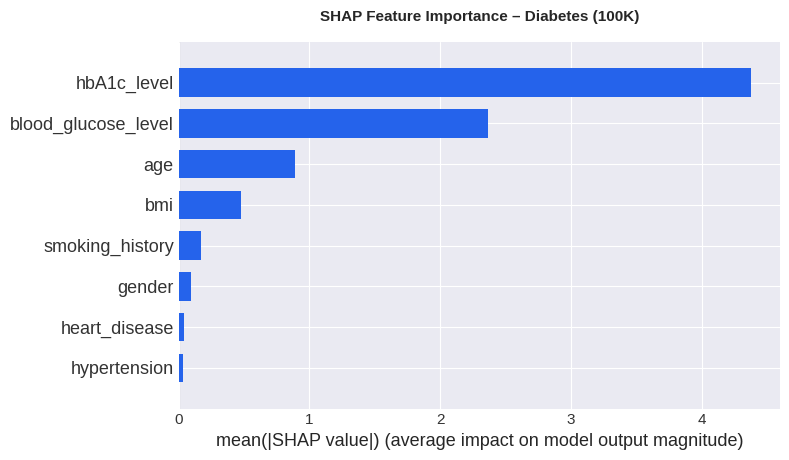

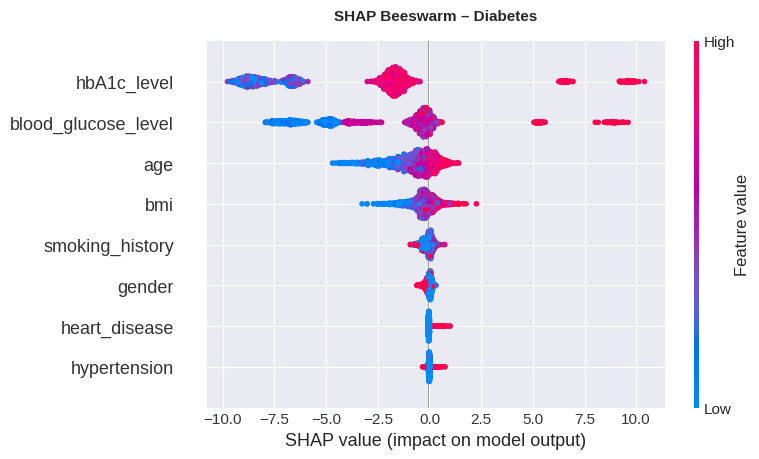

In [16]:
print("⏳ Khởi tạo SHAP TreeExplainer...")
# Với 100K mẫu, sample 2000 cho SHAP plots để nhanh hơn
np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test_d), 2000, replace=False)
X_shap_sample = X_test_d[shap_sample_idx]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap_sample)
print(f"✅ SHAP values: {shap_values.shape}  |  Base value: {explainer.expected_value:.4f}")
joblib.dump(explainer, f'{DIR_MODELS}/diabetes_shap_explainer.pkl')
print("💾 Lưu: diabetes_shap_explainer.pkl")

# Bar
plt.figure(figsize=(9,5))
shap.summary_plot(shap_values, X_shap_sample, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, color='#2563eb')
plt.title('SHAP Feature Importance – Diabetes (100K)',fontsize=11,weight='bold',pad=15)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D07_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure(figsize=(9,6))
shap.summary_plot(shap_values, X_shap_sample, feature_names=FEATURE_NAMES, show=False)
plt.title('SHAP Beeswarm – Diabetes',fontsize=11,weight='bold',pad=15)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D08_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Hàm `get_shap_explanation()` cho API

In [19]:
FEATURE_LABELS_D = {
    'age'               : 'Tuổi (năm)',
    'gender'            : 'Giới tính (0=Nữ, 1=Nam)',
    'hypertension'      : 'Tăng huyết áp (0=Không, 1=Có)',
    'heart_disease'     : 'Bệnh tim mạch (0=Không, 1=Có)',
    'smoking_history'   : 'Lịch sử hút thuốc (0=Không rõ → 4=Đang hút)',
    'bmi'               : 'Chỉ số BMI (kg/m²)',
    'hbA1c_level'       : 'HbA1c (%)',
    'blood_glucose_level': 'Đường huyết lúc đói (mg/dL)',
}

def get_shap_explanation(model_name, input_dict):
    model     = joblib.load(f'{DIR_MODELS}/{model_name}_xgboost.pkl')
    scaler    = joblib.load(f'{DIR_MODELS}/{model_name}_scaler.pkl')
    features  = joblib.load(f'{DIR_MODELS}/{model_name}_features.pkl')
    explainer = joblib.load(f'{DIR_MODELS}/{model_name}_shap_explainer.pkl')
    threshs   = joblib.load(f'{DIR_MODELS}/{model_name}_thresholds.pkl')
    opt_t     = threshs.get('f2_medical', 0.5)

    raw = [float(input_dict.get(f, 0)) for f in features]
    X_sc = scaler.transform(np.array(raw).reshape(1,-1))
    sv   = explainer.shap_values(X_sc)[0]
    prob = float(model.predict_proba(X_sc)[0][1])
    risk = 'High' if prob >= opt_t*1.5 else ('Medium' if prob >= opt_t else 'Low')

    feat_list = [{'name':f,'value':round(raw[i],2),
                  'shap_value':round(float(sv[i]),4),
                  'impact':'positive' if sv[i]>0 else 'negative',
                  'label_vn': FEATURE_LABELS_D.get(f,f)}
                 for i,f in enumerate(features)]
    feat_list.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    for r,fea in enumerate(feat_list,1): fea['rank']=r
    return {'base_value':round(float(explainer.expected_value),4),
            'prediction_prob':round(prob,4),
            'risk_level':risk, 'optimal_threshold':round(opt_t,4),
            'features':feat_list}

print("✅ Hàm get_shap_explanation() sẵn sàng!")

✅ Hàm get_shap_explanation() sẵn sàng!


### 5.3 Case Studies – Kiểm chứng Y khoa (ADA 2025)


🔴 Nguy cơ CAO
  Xác suất: 100.0%  |  Mức độ: High
    #1 HbA1c (%)                          :    7.8  SHAP=+9.464
       ℹ️  HbA1c ≥ 6.5% = tiểu đường (ADA 2025) | ≥ 5.7% = tiền tiểu đường
    #2 Tăng huyết áp (0=Không, 1=Có)      :    1.0  SHAP=+0.264
       ℹ️  Tăng huyết áp đi kèm tăng nguy cơ tiểu đường type 2
    #3 Bệnh tim mạch (0=Không, 1=Có)      :    1.0  SHAP=+0.252
    #4 Chỉ số BMI (kg/m²)                 :   34.5  SHAP=+0.186
       ℹ️  BMI ≥ 25 (Châu Á) = thừa cân → tăng kháng insulin

🟡 Nguy cơ TRUNG BÌNH
  Xác suất: 13.4%  |  Mức độ: Low
    #1 HbA1c (%)                          :    6.2  SHAP=-1.538
       ℹ️  HbA1c ≥ 6.5% = tiểu đường (ADA 2025) | ≥ 5.7% = tiền tiểu đường
    #2 Tuổi (năm)                         :   44.0  SHAP=-0.361
    #3 Lịch sử hút thuốc (0=Không rõ → 4=Đang hút):    3.0  SHAP=+0.285
    #4 Giới tính (0=Nữ, 1=Nam)            :    1.0  SHAP=-0.234

🟢 Nguy cơ THẤP
  Xác suất: 0.0%  |  Mức độ: Low
    #1 HbA1c (%)                          :    4.8

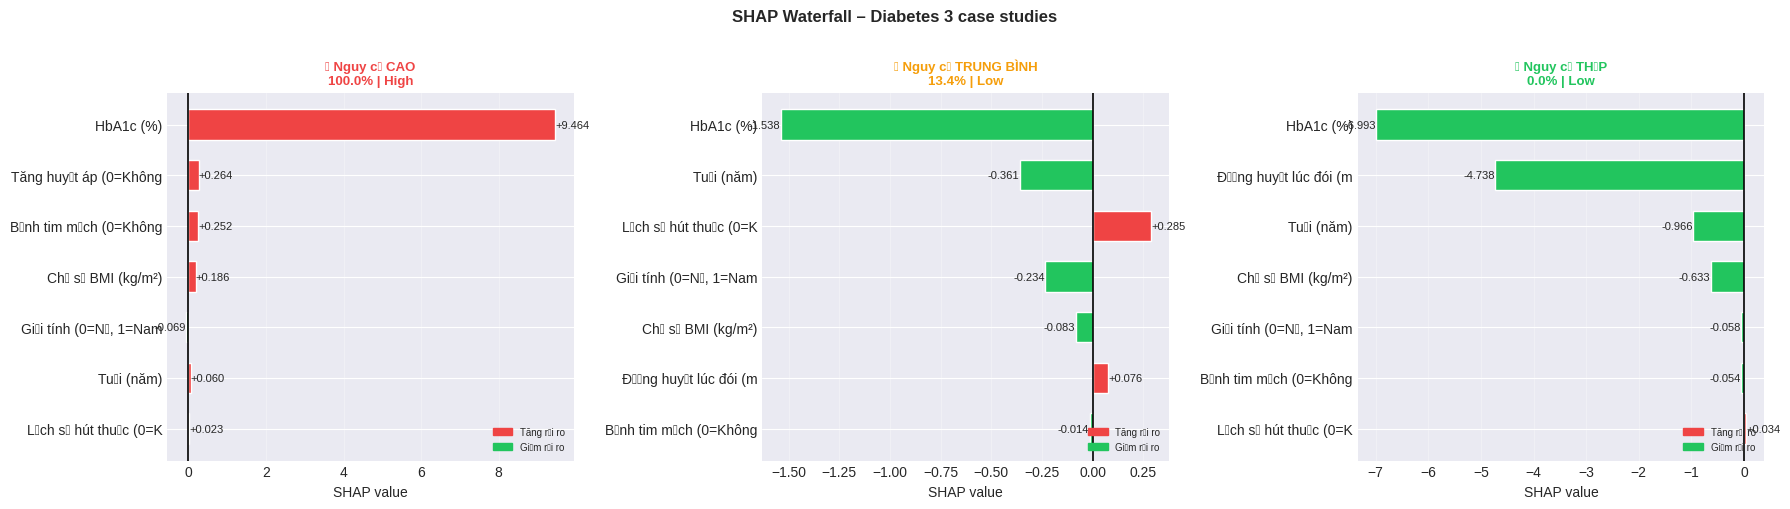

In [20]:
CASES = {
    '🔴 Nguy cơ CAO': {
        'age':58,'gender':1,'hypertension':1,'heart_disease':1,
        'smoking_history':4,'bmi':34.5,'hbA1c_level':7.8,'blood_glucose_level':200
    },
    '🟡 Nguy cơ TRUNG BÌNH': {
        'age':44,'gender':1,'hypertension':0,'heart_disease':0,
        'smoking_history':3,'bmi':28.5,'hbA1c_level':6.2,'blood_glucose_level':140
    },
    '🟢 Nguy cơ THẤP': {
        'age':27,'gender':0,'hypertension':0,'heart_disease':0,
        'smoking_history':1,'bmi':21.5,'hbA1c_level':4.8,'blood_glucose_level':90
    }
}

CLINICAL = {
    'hbA1c_level'        : "HbA1c ≥ 6.5% = tiểu đường (ADA 2025) | ≥ 5.7% = tiền tiểu đường",
    'blood_glucose_level': "Glucose ≥ 126 mg/dL = tiểu đường | 100–125 = tiền TĐ (ADA)",
    'bmi'                : "BMI ≥ 25 (Châu Á) = thừa cân → tăng kháng insulin",
    'hypertension'       : "Tăng huyết áp đi kèm tăng nguy cơ tiểu đường type 2",
}

print("=" * 70)
all_res = []
for cname, cdata in CASES.items():
    r = get_shap_explanation('diabetes', cdata)
    all_res.append((cname, cdata, r))
    print(f"\n{cname}")
    print(f"  Xác suất: {r['prediction_prob']*100:.1f}%  |  Mức độ: {r['risk_level']}")
    for feat in r['features'][:4]:
        note = CLINICAL.get(feat['name'],'')
        print(f"    #{feat['rank']} {feat['label_vn']:35s}: {feat['value']:6.1f}  SHAP={feat['shap_value']:+.3f}")
        if note: print(f"       ℹ️  {note}")

print("\n✅ Kiểm tra Y khoa:")
print("  Case CAO : HbA1c=7.8 (>6.5), Glucose=200 → SHAP dương mạnh → Đúng (ADA)")
print("  Case THẤP: HbA1c=4.8 (<5.7), Glucose=90  → SHAP âm        → Đúng")

# Waterfall
fig, axes = plt.subplots(1,3,figsize=(18,5))
colors_risk = {'🔴 Nguy cơ CAO':'#ef4444','🟡 Nguy cơ TRUNG BÌNH':'#f59e0b','🟢 Nguy cơ THẤP':'#22c55e'}
for ax,(cname,_,r) in zip(axes, all_res):
    feats = r['features'][:7]
    names = [f['label_vn'][:22] for f in feats]
    svs   = [f['shap_value'] for f in feats]
    bc    = ['#ef4444' if v>0 else '#22c55e' for v in svs]
    ax.barh(names[::-1], svs[::-1], color=bc[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='black', lw=1.2)
    for i,(name,val) in enumerate(zip(names[::-1],svs[::-1])):
        ax.text(val+(0.003 if val>=0 else -0.003), i,
                f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
    ax.set_title(f"{cname}\n{r['prediction_prob']*100:.1f}% | {r['risk_level']}",
                 fontsize=9.5, weight='bold', color=colors_risk[cname])
    ax.set_xlabel('SHAP value'); ax.grid(axis='x', alpha=0.3)
    red_p=mpatches.Patch(color='#ef4444',label='Tăng rủi ro')
    green_p=mpatches.Patch(color='#22c55e',label='Giảm rủi ro')
    ax.legend(handles=[red_p,green_p],fontsize=7,loc='lower right')
plt.suptitle('SHAP Waterfall – Diabetes 3 case studies',fontsize=12,weight='bold',y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/D09_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⏱️ PHẦN 6: DELTA FEATURES (Bug đã sửa)

In [21]:
def compute_delta_features(history: list) -> dict:
    if not history: return {}
    latest = history[-1].copy()
    numeric_keys = [k for k in latest.keys() if k != 'date']
    if len(history) >= 2:
        prev = history[-2]
        for key in numeric_keys:
            pv = prev.get(key) or 0; cv = latest.get(key) or 0
            d  = cv - pv; r = (d/pv) if pv != 0 else 0.0
            latest[f'{key}_delta'] = round(d,2)
            latest[f'{key}_delta_rate'] = round(r,4)
    if len(history) >= 3:
        for key in numeric_keys:   # ← key TRONG vòng for (đã sửa bug)
            ov = history[-3].get(key) or 0
            pv = history[-2].get(key) or 0
            cv = latest.get(key) or 0
            if   cv > pv > ov: latest[f'{key}_trend'] = 'rising'
            elif cv < pv < ov: latest[f'{key}_trend'] = 'falling'
            else:              latest[f'{key}_trend'] = 'stable'
    return latest

# Demo
history = [
    {'date':'2024-01','hbA1c_level':5.5,'blood_glucose_level':98, 'bmi':26.0},
    {'date':'2025-01','hbA1c_level':5.9,'blood_glucose_level':115,'bmi':28.1},
    {'date':'2026-01','hbA1c_level':6.3,'blood_glucose_level':138,'bmi':30.2},
]
r = compute_delta_features(history)
print("=" * 65)
print("📋 DELTA FEATURES – Bệnh nhân tiền tiểu đường tiến triển")
print("=" * 65)
print(f"  HbA1c : 5.5 → 5.9 → 6.3 %  (TĂNG DẦN ⬆️)")
print(f"  Glucose: 98 → 115 → 138 mg/dL (TĂNG DẦN ⬆️)")
for key in ['hbA1c_level','blood_glucose_level','bmi']:
    d = r.get(f'{key}_delta'); rate = r.get(f'{key}_delta_rate',0)*100
    trend = r.get(f'{key}_trend','?')
    arrow = '⬆️' if trend=='rising' else '⬇️' if trend=='falling' else '➡️'
    print(f"  {key:25s}: hiện={r.get(key):5.1f}  Δ={d:+.1f}  {rate:+.1f}%  {trend} {arrow}")

if r.get('hbA1c_level_trend') == 'rising' and r.get('hbA1c_level',0) >= 5.7:
    print(f"\n⚠️  CẢNH BÁO: HbA1c đang tăng liên tục và vào vùng TIỀN TIỂU ĐƯỜNG (≥5.7%)")
print("\n✅ Delta features hoạt động đúng!")

📋 DELTA FEATURES – Bệnh nhân tiền tiểu đường tiến triển
  HbA1c : 5.5 → 5.9 → 6.3 %  (TĂNG DẦN ⬆️)
  Glucose: 98 → 115 → 138 mg/dL (TĂNG DẦN ⬆️)
  hbA1c_level              : hiện=  6.3  Δ=+0.4  +6.8%  rising ⬆️
  blood_glucose_level      : hiện=138.0  Δ=+23.0  +20.0%  rising ⬆️
  bmi                      : hiện= 30.2  Δ=+2.1  +7.5%  rising ⬆️

⚠️  CẢNH BÁO: HbA1c đang tăng liên tục và vào vùng TIỀN TIỂU ĐƯỜNG (≥5.7%)

✅ Delta features hoạt động đúng!


---
## ✅ TỔNG KẾT

In [22]:
print("="*68)
print("📦 ARTIFACTS ĐÃ TẠO")
print("="*68)
artifacts = {
    f'{DIR_MODELS}/diabetes_xgboost.pkl'       : 'XGBoost (100K mẫu)',
    f'{DIR_MODELS}/diabetes_randomforest.pkl'  : 'Random Forest (baseline)',
    f'{DIR_MODELS}/diabetes_shap_explainer.pkl': 'SHAP Explainer',
    f'{DIR_MODELS}/diabetes_scaler.pkl'        : 'StandardScaler',
    f'{DIR_MODELS}/diabetes_features.pkl'      : f'Features: {FEATURE_NAMES}',
    f'{DIR_MODELS}/diabetes_thresholds.pkl'    : 'Thresholds F1/F2',
    f'{DIR_MODELS}/diabetes_test_raw.pkl'      : 'Test set raw (20K mẫu)',
}
import os
for path, desc in artifacts.items():
    ex = os.path.exists(path)
    sz = os.path.getsize(path)//1024 if ex else 0
    print(f"  {'✅' if ex else '❌'} {desc[:50]:50s} [{sz:4d}KB]")

print()
print("="*68)
print("🔄 SO SÁNH DATASET CŨ vs MỚI")
print("="*68)
rows = [
    ('Số mẫu',     '768',          '100,000'),
    ('Null values','Nhiều (0 giả)','0'),
    ('Feature HbA1c','❌ Không có','✅ Có (ADA gold standard)'),
    ('Smoking',     '❌',           '✅ Có'),
    ('Mất cân bằng','65:35',        '91.5:8.5 → SMOTE'),
    ('Data leakage','Không có',     'clinical_notes → ĐÃ DROP'),
]
print(f"  {'Tiêu chí':20s} │ {'Pima (cũ)':22s} │ Dataset mới")
print("  " + "─"*62)
for r,o,n in rows:
    print(f"  {r:20s} │ {o:22s} │ {n}")

📦 ARTIFACTS ĐÃ TẠO
  ✅ XGBoost (100K mẫu)                                 [1139KB]
  ✅ Random Forest (baseline)                           [6079KB]
  ✅ SHAP Explainer                                     [4995KB]
  ✅ StandardScaler                                     [   1KB]
  ✅ Features: ['gender', 'age', 'hypertension', 'heart [   0KB]
  ✅ Thresholds F1/F2                                   [   0KB]
  ✅ Test set raw (20K mẫu)                             [1406KB]

🔄 SO SÁNH DATASET CŨ vs MỚI
  Tiêu chí             │ Pima (cũ)              │ Dataset mới
  ──────────────────────────────────────────────────────────────
  Số mẫu               │ 768                    │ 100,000
  Null values          │ Nhiều (0 giả)          │ 0
  Feature HbA1c        │ ❌ Không có             │ ✅ Có (ADA gold standard)
  Smoking              │ ❌                      │ ✅ Có
  Mất cân bằng         │ 65:35                  │ 91.5:8.5 → SMOTE
  Data leakage         │ Không có               │ clinical_notes → ĐÃ 